In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
df = pd.read_csv("cleanGooglePlaystore.csv")
df

,App,Reviews,Size,Installs,isFree,Price,Content Rating_Adult,Content Rating_Everyone,Content Rating_Teen,Year Last Updated,...,Category_PERSONALIZATION,Category_PHOTOGRAPHY,Category_PRODUCTIVITY,Category_SHOPPING,Category_SOCIAL,Category_SPORTS,Category_TOOLS,Category_TRAVEL_AND_LOCAL,Category_VIDEO_PLAYERS,Category_WEATHER
0,Photo Editor & Candy Camera & Grid & ScrapBook,159,19.000000,10000.0,1,0.0,0,1,0,2018,...,0,0,0,0,0,0,0,0,0,0
1,Coloring book moana,967,14.000000,500000.0,1,0.0,0,1,0,2018,...,0,0,0,0,0,0,0,0,0,0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",87510,8.700000,5000000.0,1,0.0,0,1,0,2018,...,0,0,0,0,0,0,0,0,0,0
3,Sketch - Draw & Paint,215644,25.000000,50000000.0,1,0.0,0,0,1,2018,...,0,0,0,0,0,0,0,0,0,0
4,Pixel Draw - Number Art Coloring Book,967,2.800000,100000.0,1,0.0,0,1,0,2018,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10835,Sya9a Maroc - FR,38,53.000000,5000.0,1,0.0,0,1,0,2017,...,0,0,0,0,0,0,0,0,0,0
10836,Fr. Mike Schmitz Audio Teachings,4,3.600000,100.0,1,0.0,0,1,0,2018,...,0,0,0,0,0,0,0,0,0,0
10837,Parkinson Exercices FR,3,9.500000,1000.0,1,0.0,0,1,0,2017,...,0,0,0,0,0,0,0,0,0,0
10838,The SCP Foundation DB fr nn5n,114,21.514505,1000.0,1,0.0,1,0,0,2015,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Step 0. Create 'Performance' labels from 'Installs'
def classify_performance(installs):
    if installs < 10000:
        return 'Low'
    elif installs < 1000000:
        return 'Medium'
    else:
        return 'High'

df['Performance'] = df['Installs'].apply(classify_performance)

In [4]:
# 1. Select features and target
features = ['Reviews', 'Size', 'Price', 'Year Last Updated',
            'isFree', 'Content Rating_Adult', 'Content Rating_Everyone', 'Content Rating_Teen']  # add/remove based on your data
X = df[features]
y = df['Performance']  # assuming this column contains 'high', 'medium', 'low'

In [5]:
# 2. Scale numeric features safely
scaler = MinMaxScaler()
numeric_features = ['Reviews', 'Size', 'Price', 'Year Last Updated']

# Make an explicit copy of X to avoid chained assignment issues
X = X.copy()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

In [6]:
# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [7]:
# 4. Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

/var/folders/sq/kh7k8_rd42j3f7jj6tm_x9l40000gn/T/ipykernel_9072/4226148384.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


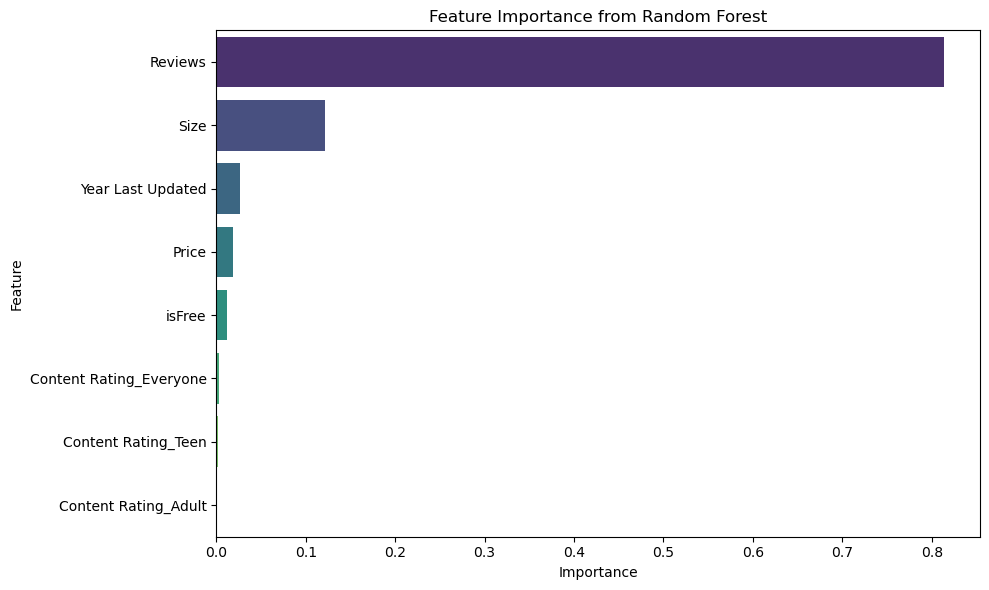

<Figure size 640x480 with 0 Axes>

In [16]:
# 5. Plot Feature Importances
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Feature Importance from Random Forest')
plt.tight_layout()
plt.show()
plt.savefig("feature importance.png")

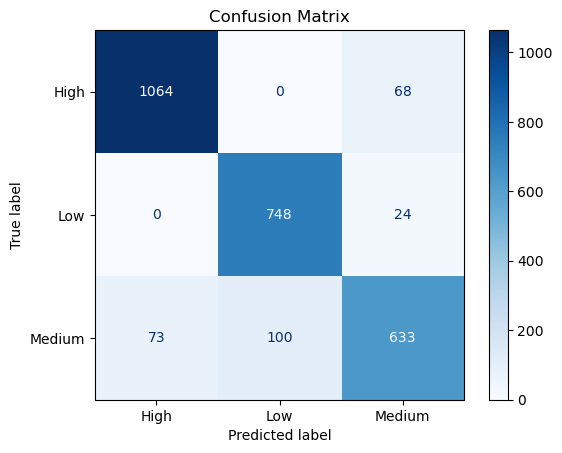

<Figure size 640x480 with 0 Axes>

In [17]:
# 6. Plot Confusion Matrix
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()
plt.savefig("confmat")

[Text(0.22421468379000345, 0.975, 'Content Rating_Everyone <= 0.5\ngini = 0.661\nsamples = 5132\nvalue = [3200, 2494, 2436]\nclass = High'),
 Text(0.053144356503785274, 0.925, 'isFree <= 0.5\ngini = 0.631\nsamples = 799\nvalue = [594, 268, 375]\nclass = High'),
 Text(0.13867952014689436, 0.95, 'True  '),
 Text(0.006194081211286993, 0.875, 'Size <= 0.066\ngini = 0.561\nsamples = 34\nvalue = [4, 25, 28]\nclass = Medium'),
 Text(0.004817618719889883, 0.825, 'gini = 0.0\nsamples = 7\nvalue = [0, 10, 0]\nclass = Low'),
 Text(0.007570543702684102, 0.825, 'Content Rating_Teen <= 0.5\ngini = 0.536\nsamples = 27\nvalue = [4, 15, 28]\nclass = Medium'),
 Text(0.0027529249827942187, 0.775, 'Size <= 0.19\ngini = 0.561\nsamples = 9\nvalue = [1, 7, 6]\nclass = Low'),
 Text(0.0013764624913971094, 0.725, 'gini = 0.0\nsamples = 1\nvalue = [0, 3, 0]\nclass = Low'),
 Text(0.0041293874741913286, 0.725, 'Size <= 0.505\ngini = 0.562\nsamples = 8\nvalue = [1, 4, 6]\nclass = Medium'),
 Text(0.00275292498279421

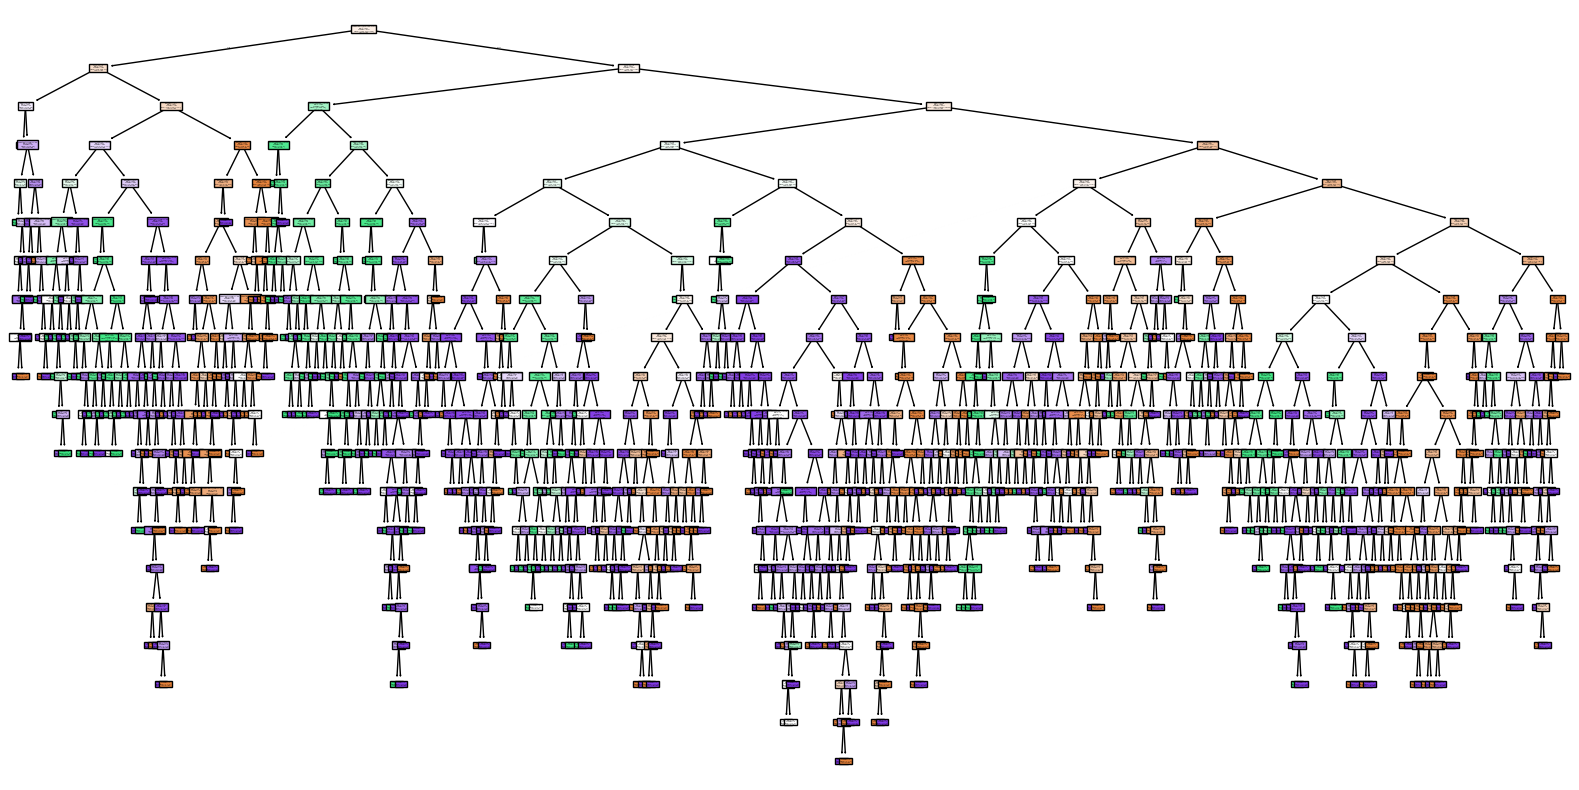

In [12]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0], feature_names=X.columns, class_names=rf.classes_, filled=True)

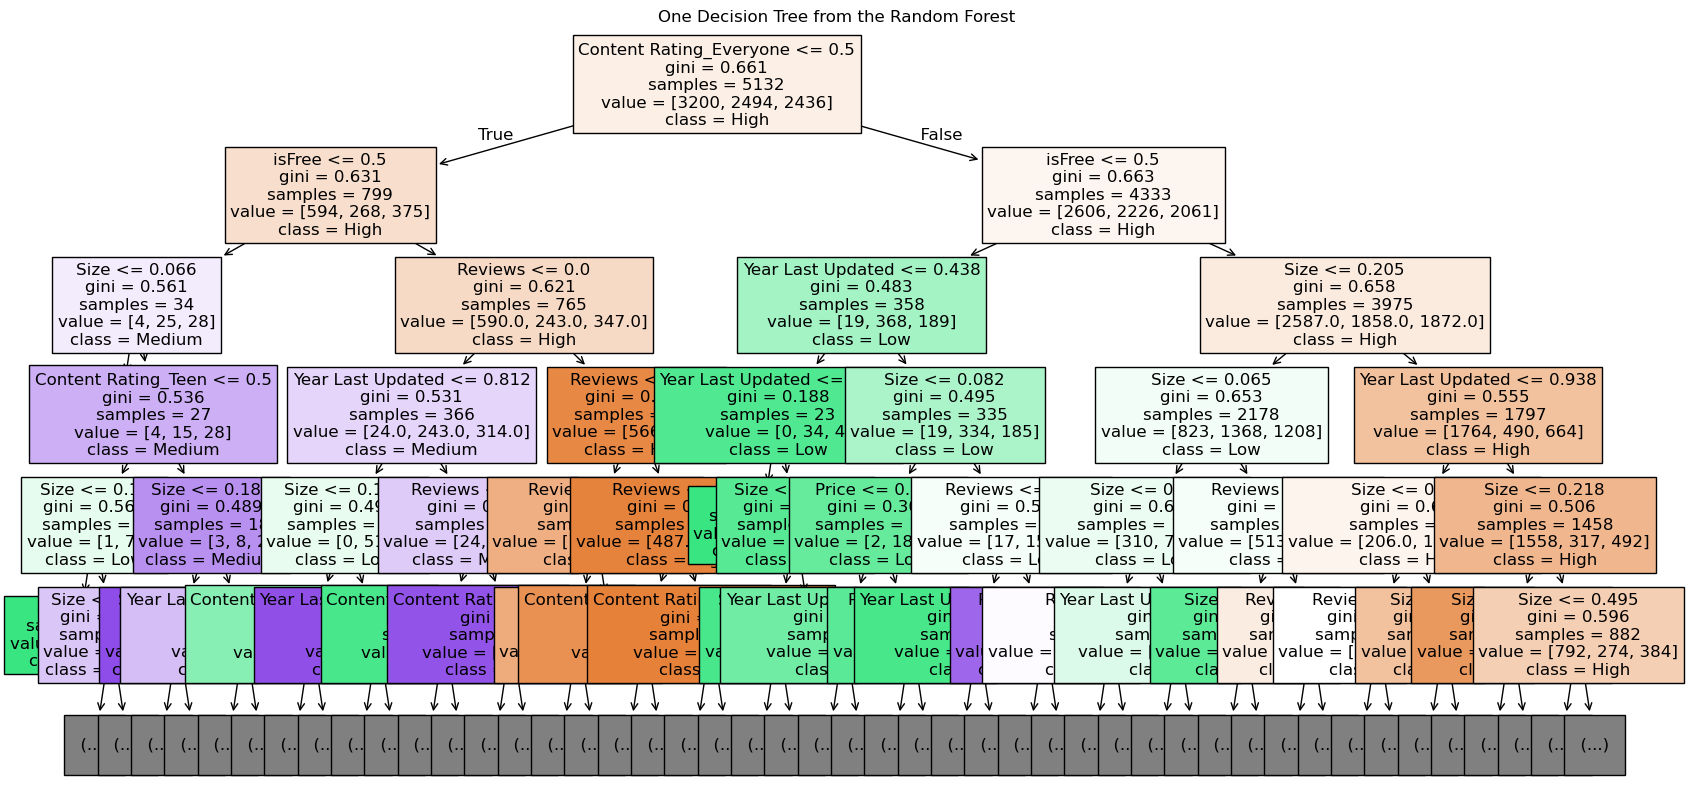

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(20,10))

# Plot one decision tree from the Random Forest with max depth of 3 and font size 12
plot_tree(rf.estimators_[0], 
          feature_names=X.columns, 
          class_names=rf.classes_, 
          filled=True, 
          max_depth=5,  # Only show top 3 levels
          fontsize=12)

# Add a title
plt.title("One Decision Tree from the Random Forest")

# Save the plot to a file (e.g., as PNG or PDF)
plt.savefig('decision_tree_limited_depth.png')  # Change the file path/format if needed

# Optionally, show the plot
plt.show()